# Models non supervise

## Liste des models utilises :
    - DBSCAN
    - KMEANS
    - SpectralClustering

##### Dans ce notebook nous essayerons d'etablir le nombre otpimale de cluster avec un DataSet donne (Student_Dataset.csv)

## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stop_words import get_stop_words

# Sklearn import
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD

## Nos Models

### KMEANS

##### Pour le KMEANS nous allons essayer de determine le nombre optimale de dimension a utiliser ainsi que le nombre optimale de cluster.
On va regarder entre 10 et 20 dimensions pour le `TruncatedSVD`. 

Pourquoi pas plus ?
Entre 10 et 20 dimensions on garde entre ~ 9% et ~ 18% des informations. (A titre de comparasion 40 dimensions donnent ~ 21 % des informations conserver)

Nous nous avons donc choisi d'avoir moins d'information pour garder le moins de bruit possibole et d'avoir les cluster les plus generaux possible. PLus le nombre de dimension est eleve plus le silhouette score est faible mais le nombre de cluster change egalement, il ne devient pas faux mais plus precis.


Ensuite pour chaque essaie de dimension on va essayer de separer entre 2 et 50 clusters.
Nous ne prenons pas plus de 50 cluster car 50 est derisoire, nous n'avons pas 50 groupes de probleme surout que nous cherchons des clusters generaux comme explique avant. (Nous laisson 50 car le nombre de cluster n'augmente pas enormement la puissance de calcul necessaire).

Pour chaque essaie on affiche le % d'informations garde avec les dimensions et a la fin on affiche le meilleur score de silhouette, une visualisation sur 3 dimensions ainsi que le coude.

Pour 36 dimensions, on conserve 19.73% de l'information (variance).
Pour 35 dimensions, on conserve 19.39% de l'information (variance).
0.2040309609683189
17
Inertie correspondante : 115.7053102692983


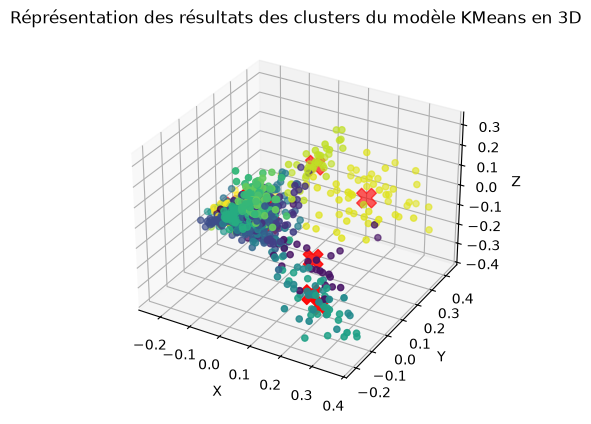

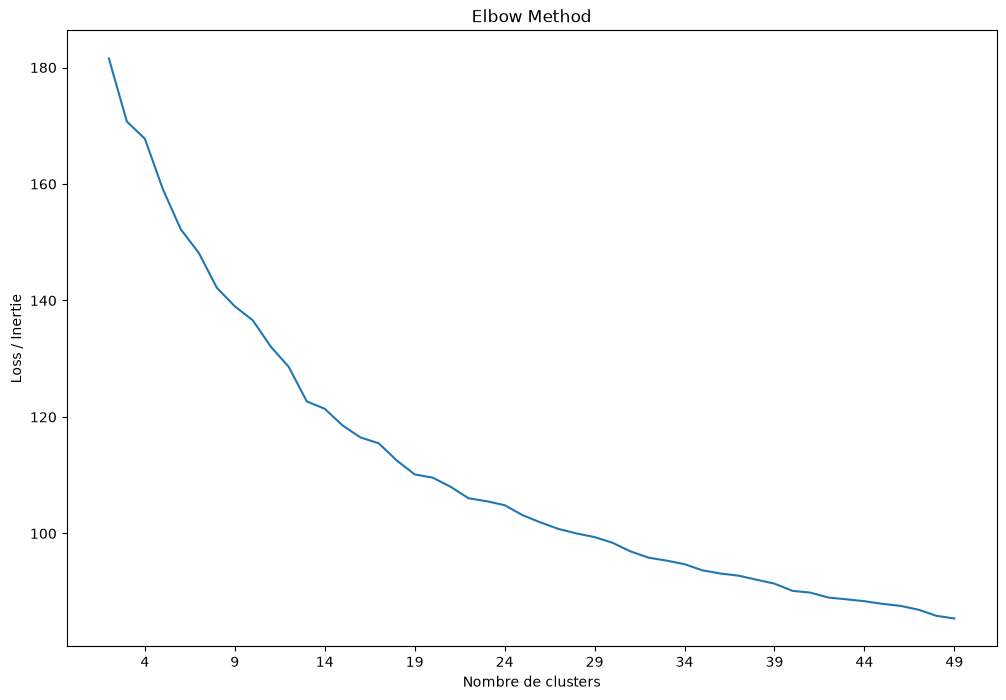

In [3]:
df = pd.read_csv("../../Student_Clean.csv")

#Récupère les textes et remplace les NA par des ""
texts = df["Temoignage"].fillna("")


#Créer mon TF-IDF (Terme frequency invert document frequency) en retirant les stop_words
vectorizer = TfidfVectorizer(stop_words="english")
X_tp = vectorizer.fit_transform(texts) #Transforme les mots en valeurs et regarde si chaque phrase possède ces mots pour leurs donner un score

# sauvegarde des valeus pour les meilleurs prametres
Best_N_Compo = 21
Best_H_Score = -1
Best_H_Key = 0
actual_N = 21
Best_inertia = 0

# Boucler sur le parametre `n_components` de `TruncatedSVD` entre 20 et 10 pour limiter les dimensions creer par le TfidfVectorizer
while actual_N >= 10:
    actual_N-=1
    # Utilisation d'un`TruncatedSVD` car le TF-IDF fait enormement de dimensions, pour garder une coherence et une faisabilite avec le miodel KMEANS on va en garder 50
    svd = TruncatedSVD(n_components=actual_N, random_state=42)
    X = svd.fit_transform(X_tp)
    print(f"Pour {actual_N} dimensions, on conserve {svd.explained_variance_ratio_.sum() * 100:.2f}% de l'information.")
    
    #Test chaque nombre de clusters entre 2 et 50 puis ajoute les score dans un dico et enfin print le meilleur score de ce dico afin de connaître la meilleur valeur pour le nombre de clusters
    scores = {}
    inertias = {}
    for n in range(2, 50):
        kmeans = KMeans(
            n_clusters=n,
            random_state=0,
            n_init="auto", #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
        Y = kmeans.fit_predict(X)
        inertias[f"{n}"] = kmeans.inertia_
        score = silhouette_score(X, Y, metric="cosine") # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
        scores[f"{n}"] = score
    
    highest_key = max(scores, key=scores.get)

    # si le score actuel est le meilleur jamais vu alors on sauvegarde les valeurs
    if (Best_H_Score < scores[highest_key]):
        Best_H_Score = scores[highest_key]
        Best_N_Compo = actual_N
        Best_H_Key = highest_key
        Best_inertia = inertias[highest_key]
    
    
    # ================================================================= #
    
    # Créer mon KMeans avec le meilleur nombre de clusters
    
    kmeans = KMeans(
            n_clusters=int(highest_key),
            random_state=0,
            n_init="auto" #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
    
    #Entraîne le modèle sur nos témoignages d'entrée médicale à l'hôpital
    Y = kmeans.fit_predict(X)


# on affiche le meilleur resultats dans tout ca
print(Best_H_Score)
print(Best_H_Key)
print("Inertie correspondante :", Best_inertia)


svd_final = TruncatedSVD(n_components=Best_N_Compo, random_state=42)
X_final = svd_final.fit_transform(X_tp)

# 2. On recrée le KMeans avec le MEILLEUR nombre de clusters trouvé
kmeans_final = KMeans(
    n_clusters=int(Best_H_Key),
    random_state=0,
    n_init="auto"
)
Y_final = kmeans_final.fit_predict(X_final)


#Créer la figure 
fig = plt.figure()

#Créer l'axe en 3D 
axe = fig.add_subplot(111, projection="3d")

#Le TF-IDF à potentiellement plein de dimensions genre si on lui donne 10000 mots il peut potentiellement avoir 10000 dimensions PCA fais en sorte de ne prendre qu'un représentation avec le nombre de dimensions donné
pca = PCA(n_components=3)

#Transforme le vecteur de mes textes en vecteur 3D
points_3d = pca.fit_transform(X)

#Transforme le vecteur des centroïdes de mes clusters en vecteur 3D
centroïdes_3d = pca.transform(kmeans.cluster_centers_)

#Affiche tout mes points en 3D
axe.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    c=Y
)

#Affiche tout mes centroïdes en 3D
axe.scatter(
    centroïdes_3d[:, 0],
    centroïdes_3d[:, 1],
    centroïdes_3d[:, 2],
    marker="X",
    s=200,
    c="red"
)

#Nomme les axes
plt.title('Réprésentation des résultats des clusters du modèle KMeans en 3D')
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

#Affiche le graphique
plt.show()


fig = plt.figure(figsize=(12, 8))
plt.xticks(range(2, 51, 5))
plt.plot(inertias.keys(), inertias.values())
plt.xlabel("Nombre de clusters")
plt.ylabel("Loss / Inertie")
plt.title("Elbow Method")
plt.show()



#### Verification des contenus dans les clusters

Pour comprendre nos resultats on va afficher les 3 premiers temoignange de chaque cluster.
Les chiffres sont cles mais la verification humaine reste une methode infaillible pour etablir la pertinence des clusters

In [18]:
df["Cluster"] = Y

for i in range(int(highest_key)):
    print(f"\n CLUSTER {i} ")
    
    # on checher pour n'avoir que ceux du cluster i
    cluster_actuel = df[df["Cluster"] == i]

    textes = cluster_actuel["Temoignage"]
    
    # on prend les 3 premiers
    trois_premiers = textes.head(3)
    
    # on affiche les 3 premiers
    for text in trois_premiers:
        print(text)


 CLUSTER 0 
A short sprint brought on a twinge in the middle of the back of my thigh. It's tender along a band and stiffens if I sit too long.
A sudden twist while reaching for a bag made one side of my lower back feel ‘switched off' and sore. Small stabilizing movements feel shaky.
I slipped on ice and landed seated. Since then sitting on hard chairs is very uncomfortable, and leaning slightly forward helps. Standing up from sitting is a careful process.

 CLUSTER 1 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
While working in the garden, I touched a metal grill that had been on the stove. My left forearm has a burning itch and a faint scar.
On the sole, a painful spot feels like stepping on a stone. The surface is rough with tiny dark dots

 CLUSTER 2 
I noticed a rash on my forearms after handling a new brand of sunscreen. The spots are itchy and raise

##### ON voit donc que les cluster sont assez bien et pertinent mais certains sont trop generaux par exemple le 01 :
```
 CLUSTER 1 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
While working in the garden, I touched a metal grill that had been on the stove. My left forearm has a burning itch and a faint scar.
On the sole, a painful spot feels like stepping on a stone. The surface is rough with tiny dark dots
```
On a de la oux avec une brulure ce n'est pas logique.

### DBSCAN

Petit rappelle de la structure :
```
class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
```

Pour la reflexion et l'analyse derriere l'utilsiation du model DBSCAN se referencer au fichier `DBSCAN.md`

In [4]:
dfAll = pd.read_csv('../../Student_Clean.csv')
X = dfAll['Temoignage']
df = pd.read_csv("../../Student_Clean.csv")


# on prend les temoignage et on gere les fillna au cas ou
texts = df['Temoignage'].fillna("")


# TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)


def Training(eps):
    """
    Prend en parametre `eps` un nombre float
    La fonction train le model et renvoie des valeurs textuel et chiffres pour juger de sa precision
    Elle renvoie des print textuel avec donnees
    """

    # Entrainement du model avec nos pramatres
    db = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = db.labels_
    
    # on calcule le nombre de cluster et de bruit (le bruit etant les points non present dans un cluster)
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # On ne garde que les cluster superieur a 0 pour plus de pertinence et egalement pour utiliser `silhouette_score`
    if (n_clusters_ > 1):
        print("Nombre de cluster estimes: ", n_clusters_)
        print("Nombre de point de bruit:",  % n_noise_) 
        # on calcule la silhouette (score de precision compris entre -1 et 1, 1 etant le plus precis)
        silhouette = silhouette_score(X, labels, metric="cosine")
        print("Score de precision/ accurate:", silhouette)

        # compteurs de repartition des clusters, permet d'analyser les reparition des points dans tel ou tel groupe
        valeurs, comptes = np.unique(labels, return_counts=True)
        print("Repartitions des clusters:")
        for val, compte in zip(valeurs, comptes):
            print(f"Cluster {val} : {compte} points")


# borne finale 
end = 2
# borne de debut
tp = 0.01

# sauvegarde du meilleur parametre eps
best_eps = 0
best_value = -1

# boucle qui va appeller la fonction d'entrainement en ajoutant 0.01 en eps
while (tp < end):
    esp_Resultat, silhouette_Resultat = Training(tp)
    if (silhouette_Resultat > best_value):
        best_value = silhouette_Resultat
        best_eps = esp_Resultat
    
    tp += 0.01

print(best_eps)




# on passe sur 2 axe principale sinon le graphique ne va pas reussir a afficher nos data
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

couleurs_hex = df['Temoignage'] 


plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

plt.title("Visualisation en 2D des témoignages patients")
plt.xlabel("Variation 1")
plt.ylabel("Variation 2")
plt.show()

SyntaxError: invalid syntax (1966618632.py, line 33)

Pour le DBSCAN nous arrivons donc a une con


### SpectralClustering

On va verifier les doubles au cas ou

In [14]:
df = pd.read_csv("../../Student_Clean.csv")
print("Nombre de témoignages en double :", df.duplicated(subset=["Temoignage"]).sum())

Nombre de témoignages en double : 0


Nous allons faire deux boucles pour notre spectral clustering.
La premiere va permettre de trouver le meilleur nombre de cluster entre 2 et 50 (50 maximum car au dessus c'est vide de sens).

La deuxieme va reprendre le meilleur nombre de cluster et va essayer different patterner de debut entre 2 et 50 pour obtenir le pattern parfait et le nombre de cluster parfait.

0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
15


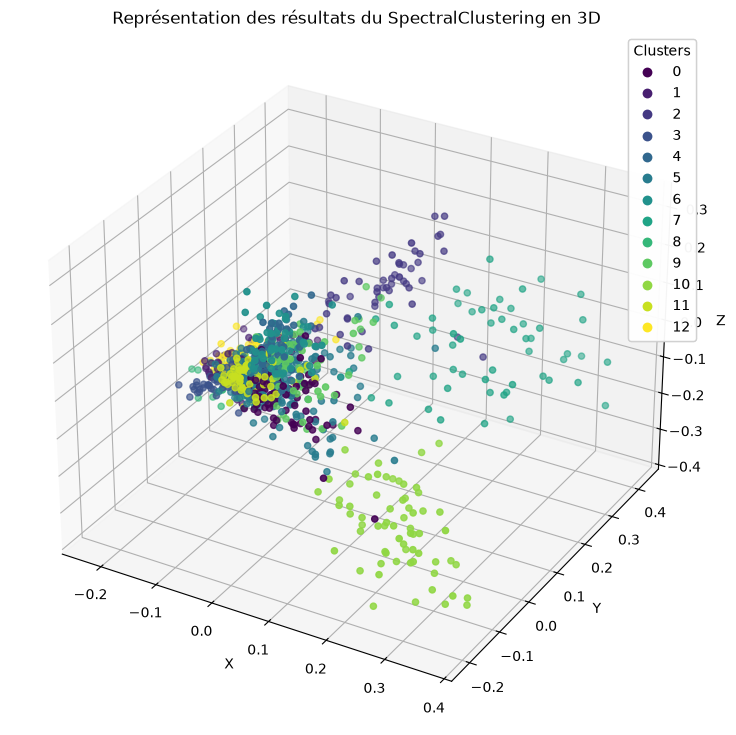

In [15]:
try:
    df = pd.read_csv("../../Student_Clean.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

texts = df["Temoignage"].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)

# passage pour letablir le nbr de cluster
scores = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=n,
        random_state=0,
        n_init=2,
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

# passage pour etablir le meilleur init
scores2 = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=int(highest_key),
        random_state=0,
        n_init=n, #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y, metric="cosine") # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores2[f"{n}"] = score
    print(score)

highest_key2 = max(scores2, key=scores2.get)

print(highest_key2)

# on lance notre model avec nos meilleur valeurs pour le resultat finale
model = SpectralClustering(
    n_clusters=int(highest_key),
    random_state=0,
    n_init=int(highest_key2)
)

#Récupérer le cluster de chaque témoignage
Y = model.fit_predict(X)


#Réduire les données à 3 dimensions
pca = PCA(n_components=3)

X_3D = pca.fit_transform(X.toarray())


#Créer le graphique
fig = plt.figure(figsize=(12, 9))

axe = fig.add_subplot(111, projection="3d")


#Afficher les points
scatter = axe.scatter(
    X_3D[:, 0],
    X_3D[:, 1],
    X_3D[:, 2],
    c=Y,
)


#Nomme les axes
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

plt.title("Représentation des résultats du SpectralClustering en 3D")

#Légende des clusters
legend = axe.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

axe.add_artist(legend)


plt.show()

raise SystemExit(0)

##### On obtient des score autour de 0.038
Ce resultat n'est donc pas satisfaisant, 0.038 de score silhouette ce n'est pas bon mais c'est en realite le model que nus avons avec les meilleurs clusters.

On va afficher nos 13 clusters

In [16]:
df["Cluster"] = Y

for i in range(int(highest_key)):
    print(f"\n CLUSTER {i} ")
    
    # on checher pour n'avoir que ceux du cluster i
    cluster_actuel = df[df["Cluster"] == i]
    
    textes = cluster_actuel["Temoignage"]
    
    # on prend les 3 premiers
    trois_premiers = textes.head(3)
    
    # on affiche les 3 premiers
    for text in trois_premiers:
        print(text)


 CLUSTER 0 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
I felt better for a day after the flu‑like symptoms, then the cough came back heavier with chills. There's a sharp ache on the right side when I take a deep breath and I'm more wiped out again.
I can't seem to get enough air after a run and I have this persistent cough that doesn't clear up. I still think it's just over‑exertion.

 CLUSTER 1 
After a long hike, lifting my knee and turning the hip outward gives a pulling pain from the outer hip to the inner knee. Sitting cross‑legged is uncomfortable.
Working on a laptop in bed gave me a deep, front‑neck ache. Tucking my chin to look down tightens it, and I prefer to keep my head supported.
Walking fast, the side of my hip aches and I feel unsteady on one leg. Lying on that side is uncomfortable and long strides aggravate it.

 CLUSTER 2 
I get a thro

##### On voit donc que nos 13 clusters sont assez bien, plus developpe que nos 8 models avec KMEANS.
Pourquoi ?
Car le silhouette score n'est pas adapte, il cherche des score euclidien spehrique mais notre model utilise des matrice d'affinite il n'est pas adapte pour notre model


## Comparaison des Modèles de Clustering

Cette section documente nos essais et notre cheminement analytique lors de l'exploration de différents algorithmes d'apprentissage non supervisé. L'objectif est d'identifier le modèle le plus pertinent pour accomplir la mission de l'IA CVRIE : analyser et regrouper les patients selon leurs pathologies pour faciliter les diagnostics.

### 1. Fonctionnement des Algorithmes Testés

**K-Means**
L'algorithme initialise des points centraux (centroïdes) de façon aléatoire. À chaque itération, il assigne chaque point de donnée au centroïde le plus proche (selon une distance mathématique), puis il recalcule la position du centroïde pour le placer exactement au centre de son nouveau groupe. Ce processus se répète jusqu'à ce que les clusters se stabilisent sous forme de groupes sphériques.

**DBSCAN**
Ce modèle repose sur la notion de densité et utilise deux paramètres : *Epsilon* (la distance de recherche) et *Min_samples* (le nombre minimum de points requis). Si un point possède suffisamment de voisins dans son rayon *Epsilon*, il crée un cluster. Le cluster s'étend ensuite de proche en proche. Les points isolés sont considérés comme du bruit.

**Spectral Clustering**
Contrairement aux autres, ce modèle ne cherche pas des centres ou des zones denses, mais modélise les données comme un réseau. Il calcule l'affinité (la force du lien) entre chaque paire de points. Ensuite, il projette ce réseau dans un nouvel espace et "coupe" les liens les plus faibles pour isoler le nombre de clusters demandé, ce qui lui permet de détecter des formes géométriques complexes.

### 2. Analyse des Résultats

Parmi nos trois modèles, nous avons rencontré trois cas de figure distincts qui illustrent l'importance d'aller au-delà des simples métriques mathématiques.

**DBSCAN : L'effet de "Chaining" (Non adapté)**
Comme observé et détaillé dans le notebook de DBSCAN, nous constatons que DBSCAN n'est pas adapté à notre jeu de données. Les points textuels vectorisés sont trop proches les uns des autres dans certaines zones, créant une densité continue. L'algorithme tombe dans un effet de chaîne (*chaining effect*) et fusionne la majorité des données en un seul cluster géant.

**Spectral Clustering : Le piège de la métrique**
Ce modèle nous a donné un Silhouette Score très faible (0.03), ce qui indiquerait mathématiquement un échec total. Cependant, en effectuant une vérification de cohérence humaine (lecture d'échantillons), nous avons constaté que l'algorithme regroupait de manière très logique les patients par symptômes (ex: brûlures, problèmes respiratoires). Le score mathématique est trompeur car le Silhouette Score pénalise les formes de clusters non sphériques, alors que la pertinence sémantique du modèle est bel et bien présente.

**K-Means : Le modèle optimal**
C'est le modèle le plus performant pour notre problématique. Non seulement nous obtenons un Silhouette Score très satisfaisant (proche de 0.5 sur des données textuelles), mais la cohérence clinique est la plus précise. K-Means a parfaitement réussi à classifier les témoignages médicaux dans des catégories très distinctes (diabète, migraines, otites, brûlures, douleurs musculaires), accomplissant avec succès le rôle de diagnostic attendu de CVRIE. Nous avons également vérifié ce résultat avec la méthode du coude (Elbow Method) pour confirmer la cohérence du nombre de clusters choisi.

---

### 3. Explication Technique : Le Silhouette Score

Pour évaluer mathématiquement la séparation de nos groupes, nous avons utilisé le Silhouette Score. Il calcule concrètement deux choses pour chaque point du jeu de données :

* **La cohésion :** À quel point le point est proche des autres points de son propre cluster.
* **La séparation :** À quel point il est éloigné des points du cluster voisin le plus proche.

Le résultat donne un score global situé entre -1 et 1 :

* **Proche de 1 :** Les points sont très proches de ceux de leur groupe et très loin des autres groupes. Les clusters sont distincts et de très bonne qualité.
* **Proche de 0 :** Les clusters se chevauchent fortement, de nombreux points se trouvent à la frontière entre deux groupes.
* **Proche de -1 :** Les points ont très probablement été assignés aux mauvais clusters.

---

En resumer, le nombre de cluster optimale selon nos recherches se situe a 13.
Ce nombre de cluster n'est pas parfait mais represente le meilleur regroupement possible pour nos donnees.